# FWI vs. Key Climate Drivers — MRI-ESM2-0 hursmin (Thailand)

**Part 1 — Computation:** Loads raw CMIP6 data, computes area-weighted annual means, and caches results to NetCDF.

## 1  Dependencies

Import `numpy`, `xarray`, `scipy`, `matplotlib`, and `pathlib`. The NetCDF4 engine is required for `xarray.open_mfdataset`.

In [3]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from pathlib import Path
import glob as _glob
import glob
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from scipy.stats import linregress


## 2  Configuration

Edit `DATA_ROOT` to point to your local data directory, then run all cells in order.


In [5]:
# ── User configuration ───────────────────────────────────────────────────────
FWI_ROOT    = Path("/Volumes/jubjang/Jubjang/FWIminimumRH")   # FWI (hursmin) files
VAR_ROOT    = Path("/Volumes/jubjang/Jubjang")                    # driver variables
OUTPUT_FILE = "Pict/FWI_vs_4drivers_Thailand_2x2_MRI-ESM2-0_hursmin.png"

# Study region: Thailand
TH_SLICE = dict(lat=slice(5.5, 20.5), lon=slice(97.5, 105.5))

# Ensemble members used for historical and multi-member SSPs
# (r_index, i_index) pairs
VALID_COMBINATIONS = [
    (1, 1), (1, 2), (1, 1000),
    (2, 1), (3, 1), (4, 1), (5, 1),
    (6, 1), (7, 1), (8, 1), (9, 1), (10, 1),
]
VALID_COMBINATIONS_SSP585 = [
    (1, 1), (1, 2),
    (2, 1), (3, 1), (4, 1), (5, 1),
]

# Scenario keys and display labels
SCENARIOS = [
    "historical", "ssp119", "ssp126", "ssp245",
    "ssp370", "ssp460", "ssp534", "ssp585",
]
SCENARIO_LABELS = {
    "historical": "Historical",
    "ssp119":     "SSP1-1.9",
    "ssp126":     "SSP1-2.6",
    "ssp245":     "SSP2-4.5",
    "ssp370":     "SSP3-7.0",
    "ssp460":     "SSP4-6.0",
    "ssp534":     "SSP5-3.4",
    "ssp585":     "SSP5-8.5",
}

# Colour-blind-friendly palette (Wong, 2011 + extensions)
PALETTE = {
    "historical": "#000000",
    "ssp119":     "#E69F00",
    "ssp126":     "#56B4E9",
    "ssp245":     "#009E73",
    "ssp370":     "#882255",
    "ssp460":     "#D55E00",
    "ssp534":     "#0072B2",
    "ssp585":     "#CC79A7",
}

# cftime decoder (required for MRI-ESM2-0 non-Gregorian calendars)
TIME_CODER = xr.coding.times.CFDatetimeCoder(use_cftime=True)


# Cache directory for precomputed means (NetCDF — avoids re-reading raw files)
CACHE_DIR    = Path("/Users/thunthita/ClimateChangeonWildfire/new/src/MRI-ESM2/hursmin/computed_means_MRI-ESM2-0_hursmin")


## 3  Load datasets

**Data sources**

| Data source | Parameters | Spatial res. | Temporal | Reference |
|---|---|---|---|---|
| MRI ESM2.0 (CMIP6) | tasmax, pr, sfcWind, hursmin | 1.125° × 1.125° | 1850–2100 | Yukimoto et al. (2019) |
| FWI derived from ESMs | Monthly mean FWI | 2.5° × 2.5° | 1850–2100 | Quilcaille et al. (2023) |

### Grid resolutions

| Variable | Grid | Shape |
|---|---|---|
| `fwisa` | 2.5° × 2.5° (annual) | 72 × 144 |
| `tasmax`, `pr`, `sfcWind`, `hursmin` | T160 (~1.125°) | 160 × 320 |

### Ensemble handling

Multi-member scenarios are concatenated along an `ensemble` dimension.
Single-member scenarios (SSP119, SSP434, SSP460, SSP534) have no ensemble dim.


In [7]:
def _open_glob(pattern, combine="nested", concat_dim="time", **kwargs):
    files = sorted(glob.glob(str(pattern)))
    if not files:
        raise FileNotFoundError(f"No files matched: {pattern}")
    
    return xr.open_mfdataset(
        files, 
        combine=combine, 
        concat_dim=concat_dim, 
        engine="netcdf4", 
        decode_times=TIME_CODER,
        coords="minimal", 
        compat="override", 
        **kwargs
    )

def _open_multi_member(member_file_lists, **kwargs):
    members = []
    for i, pattern in enumerate(member_file_lists):
        files = sorted(glob.glob(str(pattern)))
        if not files:
            raise FileNotFoundError(f"No files for member {i}: {pattern}")
        
        ds = xr.open_mfdataset(
            files, 
            combine="by_coords", 
            engine="netcdf4",
            decode_times=TIME_CODER,
            **kwargs
        )
        members.append(ds.assign_coords(ensemble=i))
    return xr.concat(members, dim="ensemble")


### 3a  FWI (annual, 2.5° grid)

Open Quilcaille et al. (2023) `fwisa` NetCDF files (one per scenario/member) and concatenate multi-member scenarios along an `ensemble` dimension.

In [9]:
FWI_DIR = FWI_ROOT  # hursmin FWI files are directly in FWIminimumRH/

ds_fwi = {
    "historical": _open_multi_member([
        FWI_DIR / f"fwisa_ann_MRI-ESM2-0_historical_r{r}i{i}p1f1_g025.nc"
        for r, i in VALID_COMBINATIONS
    ]),
    "ssp119": _open_multi_member([
        FWI_DIR / f"fwisa_ann_MRI-ESM2-0_ssp119_r{r}i1p1f1_g025.nc"
        for r in range(1, 6)
    ]),
    "ssp126": _open_multi_member([
        FWI_DIR / f"fwisa_ann_MRI-ESM2-0_ssp126_r{r}i1p1f1_g025.nc"
        for r in range(1, 6)
    ]),
    "ssp245": _open_multi_member([
        FWI_DIR / f"fwisa_ann_MRI-ESM2-0_ssp245_r{r}i1p1f1_g025.nc"
        for r in range(1, 6)
    ]),
    "ssp370": _open_multi_member([
        FWI_DIR / f"fwisa_ann_MRI-ESM2-0_ssp370_r{r}i1p1f1_g025.nc"
        for r in range(1, 6)
    ]),
    "ssp460": _open_glob(FWI_DIR / "fwisa_ann_MRI-ESM2-0_ssp460_r1i1p1f1_g025.nc"),
    "ssp534": _open_glob(FWI_DIR / "fwisa_ann_MRI-ESM2-0_ssp534-over_r1i1p1f1_g025.nc"),
    "ssp585": _open_multi_member([
        FWI_DIR / f"fwisa_ann_MRI-ESM2-0_ssp585_r{r}i{i}p1f1_g025.nc"
        for r, i in VALID_COMBINATIONS_SSP585
    ]),
}

print("FWI datasets loaded successfully.")

FWI datasets loaded successfully.


In [10]:
dataset = ds_fwi['historical']

time = dataset['time']

time.dt.year

<xarray.DataArray 'year' (time: 165)> Size: 1kB
array([1850, 1851, 1852, 1853, 1854, 1855, 1856, 1857, 1858, 1859, 1860,
       1861, 1862, 1863, 1864, 1865, 1866, 1867, 1868, 1869, 1870, 1871,
       1872, 1873, 1874, 1875, 1876, 1877, 1878, 1879, 1880, 1881, 1882,
       1883, 1884, 1885, 1886, 1887, 1888, 1889, 1890, 1891, 1892, 1893,
       1894, 1895, 1896, 1897, 1898, 1899, 1900, 1901, 1902, 1903, 1904,
       1905, 1906, 1907, 1908, 1909, 1910, 1911, 1912, 1913, 1914, 1915,
       1916, 1917, 1918, 1919, 1920, 1921, 1922, 1923, 1924, 1925, 1926,
       1927, 1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937,
       1938, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948,
       1949, 1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959,
       1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970,
       1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981,
       1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992,
       1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003,
       2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014])
Coordinates:
  * time     (time) object 1kB 1850-07-01 06:00:00 ... 2014-07-01 06:00:00
Attributes:
    axis:           T
    long_name:      time
    standard_name:  time

In [11]:
# Extract the year using the .dt accessor
# and assign it back to the dataset as a new coordinate
dataset = dataset.assign_coords(year=dataset.time.dt.year)

# Now you can see 'year' in your coordinates
print(dataset)

<xarray.Dataset> Size: 164MB
Dimensions:   (ensemble: 12, time: 165, lat: 72, lon: 144)
Coordinates:
  * ensemble  (ensemble) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * time      (time) object 1kB 1850-07-01 06:00:00 ... 2014-07-01 06:00:00
    year      (time) int64 1kB 1850 1851 1852 1853 1854 ... 2011 2012 2013 2014
  * lat       (lat) float64 576B -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
  * lon       (lon) float64 1kB 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
Data variables:
    fwisa     (ensemble, time, lat, lon) float64 164MB dask.array<chunksize=(1, 165, 72, 144), meta=np.ndarray>
Attributes: (12/19)
    CDI:                       Climate Data Interface version 2.0.5 (https://...
    Conventions:               CF-1.6
    experiment_id:             historical
    table_id:                  ann
    source_id:                 MRI-ESM2-0
    variant_label:             r1i1p1f1
    ...                        ...
    warning_boundaries:        The variables for boundaries had a

### 3b  tasmax (monthly, T160 grid)

Open MRI-ESM2-0 `tasmax` files across all scenarios.

In [13]:
TAS_DIR = VAR_ROOT / "tasmax"

ds_tasmax = {
    "historical": _open_multi_member([
        TAS_DIR / f"tasmax_Amon_MRI-ESM2-0_historical_r{r}i{i}p1f1_gn_185001-201412.nc"
        for r, i in VALID_COMBINATIONS
    ]),
    "ssp119": _open_multi_member([
        TAS_DIR / f"tasmax_Amon_MRI-ESM2-0_ssp119_r{r}i1p1f1_gn_*.nc"
        for r in range(1, 6)
    ]),
    "ssp126": _open_multi_member([
        TAS_DIR / f"tasmax_Amon_MRI-ESM2-0_ssp126_r{r}i1p1f1_gn_*.nc"
        for r in range(1, 6)
    ]),
    "ssp245": _open_multi_member([
        TAS_DIR / f"tasmax_Amon_MRI-ESM2-0_ssp245_r{r}i1p1f1_gn*.nc"
        for r in range(1, 6)
    ]),
    "ssp370": _open_multi_member([
        TAS_DIR / f"tasmax_Amon_MRI-ESM2-0_ssp370_r{r}i1p1f1_gn_*.nc"
        for r in range(1, 6)
    ]),
    "ssp460": _open_glob(TAS_DIR / "tasmax_Amon_MRI-ESM2-0_ssp460_r1i1p1f1_gn*.nc",
                         chunks={"time": 100}),
    "ssp534": _open_glob(TAS_DIR / "tasmax_Amon_MRI-ESM2-0_ssp534-over_r1i1p1f1_gn*.nc",
                         chunks={"time": 100}),
    "ssp585": _open_multi_member(
        [TAS_DIR / f"tasmax_Amon_MRI-ESM2-0_ssp585_r{r}i{i}p1f1_gn*.nc"
         for r, i in VALID_COMBINATIONS_SSP585]
    ),
}
print("tasmax datasets loaded.")


tasmax datasets loaded.


### 3c  pr (monthly, T160 grid)

Open MRI-ESM2-0 `pr` files across all scenarios.

In [15]:
PR_DIR = VAR_ROOT / "pr"

ds_pr = {
    "historical": _open_multi_member([
        PR_DIR / f"pr_Amon_MRI-ESM2-0_historical_r{r}i{i}p1f1_gn_185001-201412.nc"
        for r, i in VALID_COMBINATIONS
    ]),
    "ssp119": _open_multi_member([
        PR_DIR / f"pr_Amon_MRI-ESM2-0_ssp119_r{r}i1p1f1_gn_*.nc"
        for r in range(1, 6)
    ]),
    "ssp126": _open_multi_member([
        PR_DIR / f"pr_Amon_MRI-ESM2-0_ssp126_r{r}i1p1f1_gn_*.nc"
        for r in range(1, 6)
    ]),
    "ssp245": _open_multi_member([
        PR_DIR / f"pr_Amon_MRI-ESM2-0_ssp245_r{r}i1p1f1_gn*.nc"
        for r in range(1, 6)
    ]),
    "ssp370": _open_multi_member([
        PR_DIR / f"pr_Amon_MRI-ESM2-0_ssp370_r{r}i1p1f1_gn_*.nc"
        for r in range(1, 6)
    ]),
    "ssp460": _open_glob(PR_DIR / "pr_Amon_MRI-ESM2-0_ssp460_r1i1p1f1_gn_*.nc"),
    "ssp534": _open_glob(PR_DIR / "pr_Amon_MRI-ESM2-0_ssp534-over_r1i1p1f1_gn*.nc",
                         chunks={"time": 100}),
    "ssp585": _open_multi_member(
        [PR_DIR / f"pr_Amon_MRI-ESM2-0_ssp585_r{r}i{i}p1f1_gn*.nc"
         for r, i in VALID_COMBINATIONS_SSP585]
    ),
}
print("pr datasets loaded.")


pr datasets loaded.


### 3d  sfcWind (monthly, T160 grid)

Open MRI-ESM2-0 `sfcWind` files across all scenarios.

In [17]:
WIND_DIR = VAR_ROOT / "sfcWind"

ds_wind = {
    "historical": _open_multi_member([
        WIND_DIR / f"sfcWind_Amon_MRI-ESM2-0_historical_r{r}i{i}p1f1_gn_185001-201412.nc"
        for r, i in VALID_COMBINATIONS
    ]),
    "ssp119": _open_multi_member([
        WIND_DIR / f"sfcWind_Amon_MRI-ESM2-0_ssp119_r{r}i1p1f1_gn_*.nc"
        for r in range(1, 6)
    ]),
    "ssp126": _open_multi_member([
        WIND_DIR / f"sfcWind_Amon_MRI-ESM2-0_ssp126_r{r}i1p1f1_gn_*.nc"
        for r in range(1, 6)
    ]),
    "ssp245": _open_multi_member([
        WIND_DIR / f"sfcWind_Amon_MRI-ESM2-0_ssp245_r{r}i1p1f1_gn*.nc"
        for r in range(1, 6)
    ]),
    "ssp370": _open_multi_member([
        WIND_DIR / f"sfcWind_Amon_MRI-ESM2-0_ssp370_r{r}i1p1f1_gn_*.nc"
        for r in range(1, 6)
    ]),
    "ssp460": _open_glob(WIND_DIR / "sfcWind_Amon_MRI-ESM2-0_ssp460_r1i1p1f1_gn_*.nc"),
    "ssp534": _open_glob(WIND_DIR / "sfcWind_Amon_MRI-ESM2-0_ssp534-over_r1i1p1f1_gn*.nc",
                         chunks={"time": 100}),
    "ssp585": _open_multi_member(
        [WIND_DIR / f"sfcWind_Amon_MRI-ESM2-0_ssp585_r{r}i{i}p1f1_gn*.nc"
         for r, i in VALID_COMBINATIONS_SSP585]
    ),
}
print("sfcWind datasets loaded.")


sfcWind datasets loaded.


### 3e  hursmin (daily, T160 grid)

Open MRI-ESM2-0 `hursmin` files across all scenarios. Daily data are aggregated to annual means later via `groupby("time.year").mean()`.

In [19]:
HURSMIN_DIR = VAR_ROOT / "hursmin"

ds_hursmin = {
    "historical": _open_multi_member([
        HURSMIN_DIR / f"hursmin_day_MRI-ESM2-0_historical_r{r}i{i}p1f1_gn_*.nc"
        for r, i in VALID_COMBINATIONS
    ], combine_attrs="drop_conflicts", chunks={"time": 365}),
    "ssp119": _open_multi_member([
        HURSMIN_DIR / f"hursmin_day_MRI-ESM2-0_ssp119_r{r}i1p1f1_gn_*.nc"
        for r in range(1, 6)
    ], combine_attrs="drop_conflicts", chunks={"time": 365}),
    "ssp126": _open_multi_member([
        HURSMIN_DIR / f"hursmin_day_MRI-ESM2-0_ssp126_r{r}i1p1f1_gn_*.nc"
        for r in range(1, 6)
    ], combine_attrs="drop_conflicts", chunks={"time": 365}),
    "ssp245": _open_multi_member([
        HURSMIN_DIR / f"hursmin_day_MRI-ESM2-0_ssp245_r{r}i1p1f1_gn_*.nc"
        for r in range(1, 6)
    ], combine_attrs="drop_conflicts", chunks={"time": 365}),
    "ssp370": _open_multi_member([
        HURSMIN_DIR / f"hursmin_day_MRI-ESM2-0_ssp370_r{r}i1p1f1_gn_*.nc"
        for r in range(1, 6)
    ], combine_attrs="drop_conflicts", chunks={"time": 365}),
    "ssp460": _open_glob(HURSMIN_DIR / "hursmin_day_MRI-ESM2-0_ssp460_r1i1p1f1_gn_*.nc",
                         chunks={"time": 365}),
    "ssp534": _open_glob(HURSMIN_DIR / "hursmin_day_MRI-ESM2-0_ssp534-over_r1i1p1f1_gn_*.nc",
                         chunks={"time": 365}),
    "ssp585": _open_multi_member([
        HURSMIN_DIR / f"hursmin_day_MRI-ESM2-0_ssp585_r{r}i{i}p1f1_gn_*.nc"
        for r, i in VALID_COMBINATIONS_SSP585
    ], combine_attrs="drop_conflicts", chunks={"time": 365}),
}
print("hursmin datasets loaded.")

/opt/anaconda3/lib/python3.12/site-packages/xarray/core/indexing.py:1836: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]
/opt/anaconda3/lib/python3.12/site-packages/xarray/core/indexing.py:1836: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]


hursmin datasets loaded.


## 4  Compute grid-cell area weights

Two area grids are needed because FWI and the driver variables live on different grids:

| Grid | Shape | Used for |
|---|---|---|
| `areacella` | 72 × 144 | FWI (2.5° × 2.5° grid) |
| `areacella_drv` | 160 × 320 | tasmax / pr / sfcWind / hursmin (T160 grid) |

Grid-cell areas are derived from the spherical Earth formula:
$$A_i = R^2 \, \Delta\lambda \, (\sin\phi_2 - \sin\phi_1)$$


In [21]:
def _compute_areacella(lat_coords: np.ndarray, lon_coords: np.ndarray) -> xr.Dataset:
    """
    Return an xr.Dataset with variable ``area`` (km²) on the supplied lat/lon grid.
    """
    R = 6_378_137.0  # WGS-84 mean radius (m)
    lat_rad = np.radians(lat_coords)
    lon_rad = np.radians(lon_coords)
    d_lon = np.diff(lon_rad).mean()
    d_lat = np.diff(lat_rad).mean()

    area = np.zeros((len(lat_rad), len(lon_rad)))
    for i, phi in enumerate(lat_rad):
        phi1 = phi - d_lat / 2
        phi2 = phi + d_lat / 2
        area[i, :] = R**2 * d_lon * (np.sin(phi2) - np.sin(phi1))

    return xr.Dataset({
        "area": xr.DataArray(
            area / 1e6,          # m² → km²
            dims=["lat", "lon"],
            coords={"lat": lat_coords, "lon": lon_coords},
            attrs={"units": "km2", "long_name": "grid-cell area"},
        )
    })


# FWI grid  (72 lat × 144 lon) — analytical (no model areacella file for 2.5° grid)
areacella = _compute_areacella(
    lat_coords=np.linspace(-88.75,  88.75,  72),
    lon_coords=np.linspace(  1.25, 358.75, 144),
)

# Driver grid — load actual MRI-ESM2-0 model areacella file (same for all SSPs)
_areacella_drv_file = VAR_ROOT / "pr" / "areacella_fx_MRI-ESM2-0_ssp370_r1i1p1f1_gn.nc"
_areacella_drv_raw  = xr.open_dataset(_areacella_drv_file)
# Rename 'areacella' variable to 'area' for consistency with helper functions
areacella_drv = _areacella_drv_raw.rename({"areacella": "area"})

print("areacella     →", areacella)
print("areacella_drv →", areacella_drv)

areacella     → <xarray.Dataset> Size: 85kB
Dimensions:  (lat: 72, lon: 144)
Coordinates:
  * lat      (lat) float64 576B -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
  * lon      (lon) float64 1kB 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
Data variables:
    area     (lat, lon) float64 83kB 1.689e+03 1.689e+03 ... 1.689e+03 1.689e+03
areacella_drv → <xarray.Dataset> Size: 216kB
Dimensions:   (lat: 160, bnds: 2, lon: 320)
Coordinates:
  * lat       (lat) float64 1kB -89.14 -88.03 -86.91 ... 86.91 88.03 89.14
  * lon       (lon) float64 3kB 0.0 1.125 2.25 3.375 ... 355.5 356.6 357.8 358.9
Dimensions without coordinates: bnds
Data variables:
    lat_bnds  (lat, bnds) float64 3kB ...
    lon_bnds  (lon, bnds) float64 5kB ...
    area      (lat, lon) float32 205kB ...
Attributes: (12/43)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            ScenarioMIP AerChemMIP
    branch_method:          standard
    branch_time_in_child:   60265.0
    branch_time_in_parent:  60265

## 5  Analysis helper functions

Define `_ensemble_mean`, `_annual_mean`, `_drop_time_dim`, `_sortby_lat`, and `_area_weighted_mean`; implement cache utilities (`_save_means`, `_load_means`, `_is_cached`) to avoid re-running the heavy spatial averaging on subsequent runs. `hursmin` is computed separately (daily input) and cached on its own.

In [23]:
def _ensemble_mean(ds: xr.Dataset) -> xr.Dataset:
    """Reduce the ensemble dimension to its mean if present; no-op otherwise."""
    if "ensemble" in ds.dims:
        return ds.mean(dim="ensemble")
    return ds


def _annual_mean(ds: xr.Dataset) -> xr.Dataset:
    """Resample monthly data to annual means (year-start label, cftime-safe)."""
    return ds.resample(time="YS").mean()


def _drop_time_dim(da: xr.Dataset) -> xr.Dataset:
    """Remove time dimension from an area Dataset if accidentally present."""
    if "time" in da.dims:
        da = da.isel(time=0)
        da = da.drop_vars([v for v in da.coords if "time" in v], errors="ignore")
    return da  # fixed: was `return daz` (NameError)


def _sortby_lat(ds: xr.Dataset) -> xr.Dataset:
    """Ensure latitude is ascending. Model files are often stored N→S (descending)."""
    if "lat" in ds.dims and float(ds.lat[0]) > float(ds.lat[-1]):
        return ds.sortby("lat")
    return ds


def _area_weighted_mean(da: xr.DataArray, weights: xr.Dataset,
                        region: dict) -> xr.DataArray:
    """
    Area-weighted spatial mean of *da* clipped to *region*.

    Parameters
    ----------
    da      : DataArray to average (must have lat/lon dims)
    weights : Dataset with an ``area`` variable on a compatible grid
    region  : dict of slice kwargs defining the study region
    """
    da_reg = da.sel(**region)
    # Select nearest area weights, then reassign coords to exactly match da_reg.
    # Without assign_coords, xarray keeps the areacella's slightly different lat/lon
    # values, causing a coordinate mismatch that makes .weighted().mean() return NaN.
    w = (
        weights
        .sel(lat=da_reg.lat, lon=da_reg.lon, method="nearest")
        ["area"]
        .assign_coords(lat=da_reg.lat, lon=da_reg.lon)
    )
    return da_reg.weighted(w).mean(dim=["lat", "lon"])


## 6  Plotting function

`plot_fwi_vs_4vars_grid` produces a 2 × 2 panel figure showing area-weighted
annual FWI (ensemble mean) against each of the four climate drivers for all
nine scenarios. A linear regression line is overlaid on each scatter cloud.

**Ensemble handling inside the function:**  
Multi-member datasets are reduced to their ensemble mean before spatial averaging,
so all scenarios are treated uniformly regardless of ensemble size.


In [25]:
def _compute_var_means_region(
    datasets_dict:   dict,
    var:             str,
    scenarios:       list,
    scenario_labels: dict,
    areacella:       xr.Dataset,
    lat_range:       tuple,
    lon_range:       tuple,
    end_year:        int  = 2100,
    area_var:        str  = "area",
    concat_kwargs:   dict = None,
) -> dict:
    """
    Area-weighted annual mean of ``var`` over a lat/lon region for all scenarios.

    Uses groupby("time.year").mean() per grid cell FIRST, then area-weights the
    small annual array — much faster for daily data than area-weighting all timesteps.
    """
    concat_kw  = concat_kwargs or {}
    result     = {}
    lat_min, lat_max   = lat_range
    _lon_min, _lon_max = lon_range

    for scen in scenarios:
        label   = scenario_labels[scen]
        dataset = datasets_dict[scen]

        if isinstance(dataset, list):
            dataset = xr.concat(dataset, dim="ensemble", **concat_kw)

        print(f"  {label}: {dataset['time'].min().values} → {dataset['time'].max().values}")

        # Clip scenarios that run beyond end_year
        if scen in ("ssp126", "ssp534", "ssp585"):
            dataset = dataset.sel(time=slice(None, f"{end_year}-12-31"))

        # ── Lat/lon selection ──────────────────────────────────────────────
        subset   = dataset[var].sel(lat=slice(lat_min, lat_max))
        area_sub = areacella.sel(lat=slice(lat_min, lat_max))

        lon_min, lon_max = _lon_min, _lon_max
        if lon_min < 0: lon_min += 360
        if lon_max < 0: lon_max += 360

        if lon_min < lon_max:
            subset   = subset.sel(lon=slice(lon_min, lon_max))
            area_sub = area_sub.sel(lon=slice(lon_min, lon_max))
        else:
            subset   = xr.concat([subset.sel(lon=slice(lon_min, 360)),
                                   subset.sel(lon=slice(0, lon_max))], dim="lon")
            area_sub = xr.concat([area_sub.sel(lon=slice(lon_min, 360)),
                                   area_sub.sel(lon=slice(0, lon_max))], dim="lon")

        # ── Ensemble mean ─────────────────────────────────────────────────────
        if "ensemble" in subset.dims:
            subset = subset.mean(dim="ensemble")

        # ── Annual mean per grid cell FIRST (60k daily → ~165 annual) ────────────────
        subset_annual = subset.groupby("time.year").mean()

        # ── Area-weighted spatial mean on small annual array ───────────────────
        result[scen] = subset_annual.weighted(area_sub[area_var]).mean(dim=["lat", "lon"])

    return result

## 7  Generate figure

Load area-weighted annual means from cache (or recompute if absent) and call `plot_fwi_vs_4vars_grid` to produce a 2 × 2 scatter panel — FWI vs tasmax, pr, sfcWind, hursmin — for all SSP scenarios. Multi-member scenarios are reduced to their ensemble mean before plotting.

In [27]:
# ── Compute fast vars (or load from cache) — fwi / tasmax / pr / sfcWind ─────
from pathlib import Path
CACHE_DIR = Path("/Users/thunthita/ClimateChangeonWildfire/new/src/MRI-ESM2/hursmin/computed_means_MRI-ESM2-0_hursmin")

def _save_means(means_dict: dict, var_name: str, cache_dir) -> None:
    cache_dir.mkdir(parents=True, exist_ok=True)
    for scen, da in means_dict.items():
        da.to_netcdf(cache_dir / f"{var_name}_{scen}.nc")
    print(f"  saved {len(means_dict)} files  ({var_name}_*.nc)")

def _load_means(var_name: str, scenarios: list, cache_dir) -> dict:
    return {
        scen: xr.open_dataarray(cache_dir / f"{var_name}_{scen}.nc")
        for scen in scenarios
        if (cache_dir / f"{var_name}_{scen}.nc").exists()
    }

def _is_cached(var_name: str, scenarios: list, cache_dir) -> bool:
    return all((cache_dir / f"{var_name}_{scen}.nc").exists() for scen in scenarios)

_lat = (TH_SLICE["lat"].start, TH_SLICE["lat"].stop)
_lon = (TH_SLICE["lon"].start, TH_SLICE["lon"].stop)
_kw  = dict(scenarios=SCENARIOS, scenario_labels=SCENARIO_LABELS,
            lat_range=_lat, lon_range=_lon, end_year=2100, area_var="area")

_fast_vars = ["fwi", "tasmax", "pr", "sfcWind"]

if all(_is_cached(v, SCENARIOS, CACHE_DIR) for v in _fast_vars):
    print("Fast vars cache found — loading from disk.")
    ensemble_means_th_all_scenarios = _load_means("fwi",     SCENARIOS, CACHE_DIR)
    tasmax_means_all_scenarios      = _load_means("tasmax",  SCENARIOS, CACHE_DIR)
    pr_means_all_scenarios          = _load_means("pr",      SCENARIOS, CACHE_DIR)
    sfcWind_means_all_scenarios     = _load_means("sfcWind", SCENARIOS, CACHE_DIR)
    for _d in [ensemble_means_th_all_scenarios, tasmax_means_all_scenarios,
               pr_means_all_scenarios, sfcWind_means_all_scenarios]:
        for _da in _d.values(): _da.load()
else:
    print("Computing fast vars from raw data...")

    print("── FWI ────────────────────────────────────────────────────────────")
    ensemble_means_th_all_scenarios = _compute_var_means_region(
        ds_fwi, "fwisa", areacella=areacella, **_kw)

    print("── tasmax ─────────────────────────────────────────────────────────")
    tasmax_means_all_scenarios = _compute_var_means_region(
        ds_tasmax, "tasmax", areacella=areacella_drv, **_kw)

    print("── pr ─────────────────────────────────────────────────────────────")
    pr_means_all_scenarios = _compute_var_means_region(
        ds_pr, "pr", areacella=areacella_drv, **_kw)

    print("── sfcWind ────────────────────────────────────────────────────────")
    sfcWind_means_all_scenarios = _compute_var_means_region(
        ds_wind, "sfcWind", areacella=areacella_drv, **_kw)

    print("Saving fast vars to cache...")
    _save_means(ensemble_means_th_all_scenarios, "fwi",     CACHE_DIR)
    _save_means(tasmax_means_all_scenarios,      "tasmax",  CACHE_DIR)
    _save_means(pr_means_all_scenarios,          "pr",      CACHE_DIR)
    _save_means(sfcWind_means_all_scenarios,     "sfcWind", CACHE_DIR)

print("Fast vars ready.")

Computing fast vars from raw data...
── FWI ────────────────────────────────────────────────────────────
  Historical: 1850-07-01 06:00:00 → 2014-07-01 06:00:00
  SSP1-1.9: 2015-07-01 06:00:00 → 2100-07-01 06:00:00
  SSP1-2.6: 2015-07-01 06:00:00 → 2100-07-01 06:00:00
  SSP2-4.5: 2015-07-01 06:00:00 → 2100-07-01 06:00:00
  SSP3-7.0: 2015-07-01 06:00:00 → 2100-07-01 06:00:00
  SSP4-6.0: 2015-07-01 06:00:00 → 2100-07-01 06:00:00
  SSP5-3.4: 2040-07-01 06:00:00 → 2100-07-01 06:00:00
  SSP5-8.5: 2015-07-01 06:00:00 → 2100-07-01 06:00:00
── tasmax ─────────────────────────────────────────────────────────
  Historical: 1850-01-16 12:00:00 → 2014-12-16 12:00:00
  SSP1-1.9: 2015-01-16 12:00:00 → 2100-12-16 12:00:00
  SSP1-2.6: 2015-01-16 12:00:00 → 2100-12-16 12:00:00
  SSP2-4.5: 2015-01-16 12:00:00 → 2100-12-16 12:00:00
  SSP3-7.0: 2015-01-16 12:00:00 → 2100-12-16 12:00:00
  SSP4-6.0: 2015-01-16 12:00:00 → 2100-12-16 12:00:00
  SSP5-3.4: 2040-01-16 12:00:00 → 2300-12-16 12:00:00
  SSP5-8.5: 2

In [28]:
def _is_cached(var_name: str, scenarios: list, cache_dir) -> bool:
    return all((cache_dir / f"{var_name}_{scen}.nc").exists() for scen in scenarios)
_lat = (TH_SLICE["lat"].start, TH_SLICE["lat"].stop)
_lon = (TH_SLICE["lon"].start, TH_SLICE["lon"].stop)
_kw  = dict(scenarios=SCENARIOS, scenario_labels=SCENARIO_LABELS,
            lat_range=_lat, lon_range=_lon, end_year=2100, area_var="area")


In [29]:
# ── Compute hursmin (daily data — slow) ───────────────────────────────────────
# Processes one scenario at a time and saves immediately — prints when each done.
import time as _time

if _is_cached("hursmin", SCENARIOS, CACHE_DIR):
    print("hursmin cache found — loading from disk.")
    hursmin_means_all_scenarios = _load_means("hursmin", SCENARIOS, CACHE_DIR)
    for _da in hursmin_means_all_scenarios.values(): _da.load()
else:
    print("Computing hursmin scenario by scenario (daily data — this will take a while)...")
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    hursmin_means_all_scenarios = {}

    for scen in SCENARIOS:
        _t0 = _time.time()
        print(f"  {scen} ...", end=" ", flush=True)

        # compute one scenario at a time
        _result = _compute_var_means_region(
            ds_hursmin, "hursmin",
            scenarios=[scen],
            scenario_labels=SCENARIO_LABELS,
            areacella=areacella_drv,
            lat_range=(_lat[0], _lat[1]),
            lon_range=(_lon[0], _lon[1]),
            end_year=2100,
            area_var="area",
            concat_kwargs={"combine_attrs": "drop_conflicts"},
        )
        da = _result[scen].compute()   # force actual computation now
        da.to_netcdf(CACHE_DIR / f"hursmin_{scen}.nc")
        hursmin_means_all_scenarios[scen] = da

        _elapsed = _time.time() - _t0
        print(f"done  ({_elapsed:.0f}s)")

print("hursmin ready.")

Computing hursmin scenario by scenario (daily data — this will take a while)...
  historical ...   Historical: 1850-01-01 12:00:00 → 2014-12-31 12:00:00
done  (324s)
  ssp119 ...   SSP1-1.9: 2015-01-01 12:00:00 → 2100-12-31 12:00:00
done  (72s)
  ssp126 ...   SSP1-2.6: 2015-01-01 12:00:00 → 2100-12-31 12:00:00
done  (72s)
  ssp245 ...   SSP2-4.5: 2015-01-01 12:00:00 → 2100-12-31 12:00:00
done  (70s)
  ssp370 ...   SSP3-7.0: 2015-01-01 12:00:00 → 2100-12-31 12:00:00
done  (73s)
  ssp460 ...   SSP4-6.0: 2015-01-01 12:00:00 → 2100-12-31 12:00:00
done  (14s)
  ssp534 ...   SSP5-3.4: 2040-01-01 12:00:00 → 2100-12-31 12:00:00
done  (10s)
  ssp585 ...   SSP5-8.5: 2015-01-01 12:00:00 → 2100-12-31 12:00:00
done  (86s)
hursmin ready.


## Standard Deviation of FWI across ensemble members

`_compute_var_stds_region` mirrors `_compute_var_means_region` exactly,
but replaces `.mean(dim="ensemble")` with `.std(dim="ensemble")` so the
area-weighted annual **spread across members** is returned instead of the mean.

In [31]:
def _compute_var_stds_region(
    datasets_dict:   dict,
    var:             str,
    scenarios:       list,
    scenario_labels: dict,
    areacella:       xr.Dataset,
    lat_range:       tuple,
    lon_range:       tuple,
    end_year:        int  = 2100,
    area_var:        str  = "area",
    concat_kwargs:   dict = None,
) -> dict:
    """
    Area-weighted annual SE (sd/sqrt(N)) across ensemble members of ``var``
    over a lat/lon region.  Single-member scenarios are skipped (SE = NaN).
    """
    concat_kw  = concat_kwargs or {}
    result     = {}
    lat_min, lat_max   = lat_range
    _lon_min, _lon_max = lon_range

    for scen in scenarios:
        label   = scenario_labels[scen]
        dataset = datasets_dict[scen]

        if isinstance(dataset, list):
            dataset = xr.concat(dataset, dim="ensemble", **concat_kw)

        # Skip single-member scenarios — SD/sqrt(1) is undefined
        if "ensemble" not in dataset.dims or dataset.sizes["ensemble"] < 2:
            print(f"  {label}: single member — skipping (SE = NaN)")
            result[scen] = xr.DataArray(float("nan"))
            continue

        if scen in ("ssp126", "ssp534", "ssp585"):
            dataset = dataset.sel(time=slice(None, f"{end_year}-12-31"))

        subset   = dataset[var].sel(lat=slice(lat_min, lat_max))
        area_sub = areacella.sel(lat=slice(lat_min, lat_max))

        lon_min, lon_max = _lon_min, _lon_max
        if lon_min < 0: lon_min += 360
        if lon_max < 0: lon_max += 360

        if lon_min < lon_max:
            subset   = subset.sel(lon=slice(lon_min, lon_max))
            area_sub = area_sub.sel(lon=slice(lon_min, lon_max))
        else:
            subset   = xr.concat([subset.sel(lon=slice(lon_min, 360)),
                                   subset.sel(lon=slice(0, lon_max))], dim="lon")
            area_sub = xr.concat([area_sub.sel(lon=slice(lon_min, 360)),
                                   area_sub.sel(lon=slice(0, lon_max))], dim="lon")

        n      = subset.sizes["ensemble"]
        subset = subset.std(dim="ensemble") / np.sqrt(n)

        subset_annual = subset.groupby("time.year").mean()
        result[scen]  = subset_annual.weighted(area_sub[area_var]).mean(dim=["lat", "lon"])
        print(f"  {scen}: done  (N={n})")

    return result


# ── Compute or load SE of FWI ─────────────────────────────────────────────────
_sd_var = "sd_fwi"
_lat    = (TH_SLICE["lat"].start, TH_SLICE["lat"].stop)
_lon    = (TH_SLICE["lon"].start, TH_SLICE["lon"].stop)

if _is_cached(_sd_var, SCENARIOS, CACHE_DIR):
    print("SE cache found — loading from disk.")
    sd_fwi_all_scenarios = _load_means(_sd_var, SCENARIOS, CACHE_DIR)
    for _da in sd_fwi_all_scenarios.values():
        _da.load()
else:
    print("Computing SE of FWI (sd/sqrt(N)) across ensemble members...")
    sd_fwi_all_scenarios = _compute_var_stds_region(
        ds_fwi, "fwisa", areacella=areacella,
        scenarios=SCENARIOS, scenario_labels=SCENARIO_LABELS,
        lat_range=_lat, lon_range=_lon, end_year=2100, area_var="area")
    _save_means(sd_fwi_all_scenarios, _sd_var, CACHE_DIR)
    print("Saved sd_fwi_*.nc →", CACHE_DIR)

print("\nSE of FWI (sd/sqrt(N), Thailand):")
for scen in SCENARIOS:
    v = sd_fwi_all_scenarios[scen]
    val = float(v.mean().values) if v.ndim > 0 else float(v.values)
    print(f"  {scen}: {val:.4f}" if not np.isnan(val) else f"  {scen}: NaN (single member)")

Computing SE of FWI (sd/sqrt(N)) across ensemble members...
  historical: done  (N=12)
  ssp119: done  (N=5)
  ssp126: done  (N=5)
  ssp245: done  (N=5)
  ssp370: done  (N=5)
  SSP4-6.0: single member — skipping (SE = NaN)
  SSP5-3.4: single member — skipping (SE = NaN)
  ssp585: done  (N=6)
  saved 8 files  (sd_fwi_*.nc)
Saved sd_fwi_*.nc → /Users/thunthita/ClimateChangeonWildfire/new/src/MRI-ESM2/hursmin/computed_means_MRI-ESM2-0_hursmin

SE of FWI (sd/sqrt(N), Thailand):
  historical: 1.2503
  ssp119: 2.0079
  ssp126: 2.0493
  ssp245: 2.0279
  ssp370: 2.1100
  ssp460: NaN (single member)
  ssp534: NaN (single member)
  ssp585: 1.9604


## FWI time series — ensemble mean ± SE

Plot the area-weighted annual FWI for each scenario as a line (ensemble mean)
with a shaded band of ±`sd/sqrt(N)` (standard error of the mean).

Figure saved → Pict/FWI_vs_4drivers_Thailand_2x2_MRI-ESM2-0_hursmin_timeseries.png


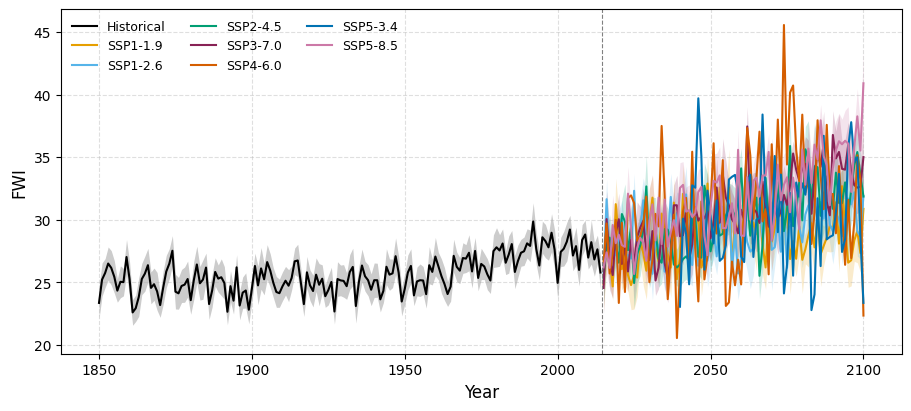

In [33]:
def plot_fwi_timeseries_with_se(
    fwi_means:  dict,
    fwi_se:     dict,
    scenarios:  list,
    labels:     dict,
    palette:    dict,
    filename:   str = OUTPUT_FILE.replace(".png", "_timeseries.png"),
) -> None:
    """
    Line plot of area-weighted annual FWI (ensemble mean) with ±SE shading.
    Historical and future scenarios are plotted on the same axis.
    """
    fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)

    for scen in scenarios:
        mean_da = fwi_means[scen]
        se_da   = fwi_se.get(scen)
        years   = mean_da["year"].values
        mean_v  = mean_da.values
        color   = palette.get(scen, "#000000")
        lbl     = labels.get(scen, scen)

        ax.plot(years, mean_v, color=color, lw=1.5, label=lbl)

        if se_da is not None and "year" in se_da.dims:
            se_v = se_da.sel(year=mean_da["year"], method="nearest").values
            if not np.all(np.isnan(se_v)):
                ax.fill_between(years,
                                mean_v - se_v,
                                mean_v + se_v,
                                color=color, alpha=0.2, linewidth=0)

    ax.axvline(2014.5, color="grey", lw=0.8, ls="--")
    ax.set_xlabel("Year", fontsize=12)
    ax.set_ylabel("FWI", fontsize=12)
    ax.legend(fontsize=9, ncol=3, frameon=False)
    ax.grid(True, linestyle="--", alpha=0.4)
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    print(f"Figure saved → {filename}")
    plt.show()


plot_fwi_timeseries_with_se(
    fwi_means = {s: xr.open_dataarray(CACHE_DIR / f"fwi_{s}.nc").load() for s in SCENARIOS
                 if (CACHE_DIR / f"fwi_{s}.nc").exists()},
    fwi_se    = {s: xr.open_dataarray(CACHE_DIR / f"sd_fwi_{s}.nc").load() for s in SCENARIOS
                 if (CACHE_DIR / f"sd_fwi_{s}.nc").exists()},
    scenarios = SCENARIOS,
    labels    = SCENARIO_LABELS,
    palette   = PALETTE,
)

In [57]:
def plot_fwi_vs_4vars_grid(
    fwi_means:    dict,
    tasmax_means: dict,
    pr_means:     dict,
    wind_means:   dict,
    hursmin_means:   dict,
    scenarios:    list,
    labels:       dict,
    palette:      dict,
    filename:     str = OUTPUT_FILE,
) -> None:
    """
    2 × 2 scatter: FWI vs four climate drivers.

    Parameters
    ----------
    fwi_means, tasmax_means, pr_means, wind_means, hursmin_means
        Each is a dict {scenario_key: xr.DataArray (1-D annual)}
        from ``_compute_var_means_region``.
    Unit conversions are applied here: tasmax K→°C, pr kg m⁻² s⁻¹→mm day⁻¹.
    """
    panels = [
        dict(key="tasmax", drv=tasmax_means, xlabel="Maximum Temperature (°C)",   label="a)"),
        dict(key="pr",     drv=pr_means,     xlabel="Precipitation (mm day⁻¹)",   label="b)"),
        dict(key="wind",   drv=wind_means,   xlabel="Surface Wind Speed (m s⁻¹)", label="c)"),
        dict(key="hursmin",   drv=hursmin_means,   xlabel="Min Relative Humidity (%)",       label="(d)"),
    ]

    fig, axes = plt.subplots(
        2, 2, figsize=(5, 4),
        constrained_layout=True, sharey="row",
    )
    axes = axes.flatten()
    legend_handles = {}

    for ax, panel in zip(axes, panels):
        var = panel["key"]
        # ax.set_title(panel["label"], loc="left", fontsize=13)

        for scen in scenarios:
            fwi_da = fwi_means[scen]
            t      = fwi_da["year"]             # FWI integer years as alignment ref
            y_vals = fwi_da.values

            drv_da = panel["drv"][scen].sel(year=t, method="nearest")

            # Unit conversion at plot time
            if var == "tasmax":
                x_vals = (drv_da - 273.15).values      # K → °C
            elif var == "pr":
                x_vals = (drv_da * 86_400.0).values    # kg m⁻² s⁻¹ → mm day⁻¹
            else:
                x_vals = drv_da.values                 # sfcWind / hursmin: no conversion

            mask = (~np.isnan(x_vals)) & (~np.isnan(y_vals))
            x_vals, y_vals = x_vals[mask], y_vals[mask]
            if x_vals.size == 0 or x_vals.size != y_vals.size:
                print(f"[skip] {scen} / {var}: size mismatch or all-NaN")
                continue

            color = palette.get(scen, "#000000")
            sc = ax.scatter(x_vals, y_vals, s=5, alpha=0.6, color=color)

            slope, intercept, *_ = linregress(x_vals, y_vals)
            x_fit = np.linspace(x_vals.min(), x_vals.max(), 100)
            ax.plot(x_fit, slope * x_fit + intercept, "-", lw=1.5, color=color)

            lbl = labels.get(scen, scen)
            if lbl not in legend_handles:
                legend_handles[lbl] = sc

        ax.set_xlabel(panel["xlabel"], fontsize=12)
        ax.set_ylim(0, 50)
        ax.grid(True, linestyle="solid", alpha=0.6)
        ax.tick_params(labelsize=11)

    for idx, ax in enumerate(axes):
        if idx % 2 == 0:
            ax.set_ylabel("FWI", fontsize=12)
        else:
            ax.set_ylabel(None)
            ax.tick_params(labelleft=False)

    fig.legend(
        legend_handles.values(), legend_handles.keys(),
        loc="upper center", bbox_to_anchor=(0.5, 0.01),
        ncol=3, frameon=False, fontsize=10,
    )
    fig.savefig(filename, dpi=1000, bbox_inches="tight")
    print(f"Figure saved → {filename}")
    plt.show()


Figure saved → Pict/FWI_vs_4drivers_Thailand_2x2_MRI-ESM2-0_hursmin.png


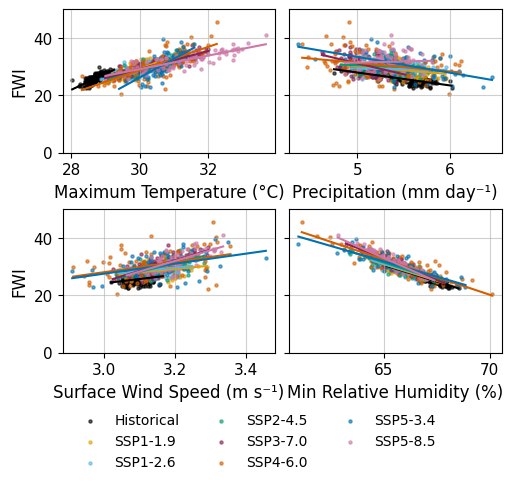

In [59]:
# ── 4-panel scatter: FWI vs 4 drivers ─────────────────────────────────────────
from pathlib import Path
_cd = Path("/Users/thunthita/ClimateChangeonWildfire/new/src/MRI-ESM2/hursmin/computed_means_MRI-ESM2-0_hursmin")
_ld = lambda v: {s: xr.open_dataarray(_cd / f"{v}_{s}.nc").load() for s in SCENARIOS if (_cd / f"{v}_{s}.nc").exists()}

plot_fwi_vs_4vars_grid(
    fwi_means    = _ld("fwi"),
    tasmax_means = _ld("tasmax"),
    pr_means     = _ld("pr"),
    wind_means   = _ld("sfcWind"),
    hursmin_means   = _ld("hursmin"),
    scenarios    = SCENARIOS,
    labels       = SCENARIO_LABELS,
    palette      = PALETTE,
    filename     = OUTPUT_FILE,
)